# ***1.  PREPARING FOR PROJECT***

In [ ]:
# 1.1. Kết nối Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install optuna -q

In [ ]:
# 1.2. Import thư viện, cấu hình các biểu đồ chỉ số

# Kết nối hệ thống & Quản lý File
from google.colab import drive
import os
import joblib
import warnings
# Xử lý dữ liệu & Tính toán toán học
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import shap
# Machine Learning Frameworks
import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
# Tối ưu hóa & Đánh giá mô hình
import optuna              # Auto-tuning Hyperparameters
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Cấu hình biểu đồ
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

# Cố định Random Seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
# Bỏ qua các cảnh báo
warnings.filterwarnings('ignore')

In [ ]:
# 1.3. Load data
base_path = '/content/drive/Shareddrives/PTDL NANG CAO - NHOM 10/ĐỒ ÁN CUỐI KỲ/data_2/'

print("Đang tải dữ liệu...")
df_customers = pd.read_csv(base_path + 'bm_customers.csv')
df_promotions = pd.read_csv(base_path + 'bm_promotions.csv')
df_skus = pd.read_csv(base_path + 'bm_skus.csv')
df_stores = pd.read_csv(base_path + 'bm_stores.csv')
df_sales = pd.read_csv(base_path + 'bm_sales_synthetic.csv')
df_inventory = pd.read_csv(base_path + 'bm_inventory_synthetic.csv')

# Chuẩn hóa DateTime
df_sales['date'] = pd.to_datetime(df_sales['date'])
df_inventory['snapshot_date'] = pd.to_datetime(df_inventory['snapshot_date'])

print("Load xong!")

Đang tải dữ liệu...
Load xong!


# ***2. EDA SƠ BỘ***

TỔNG QUAN KÍCH THƯỚC & DỮ LIỆU THIẾU (MISSING VALUES)


,Bảng,Số dòng,Số cột,Dòng trùng lặp,% Dữ liệu thiếu
0,Sales (Synthetic),641843,9,13,2.77%
1,Inventory (Synthetic),10000,7,0,0.00%
2,SKUs,200,7,0,0.00%
3,Stores,50,5,0,0.00%
4,Customers,5000,7,0,0.00%
5,Promotion,33,6,0,0.00%



PHÂN TÍCH HIỆU QUẢ KHUYẾN MÃI (DISCOUNT VS QUANTITY)


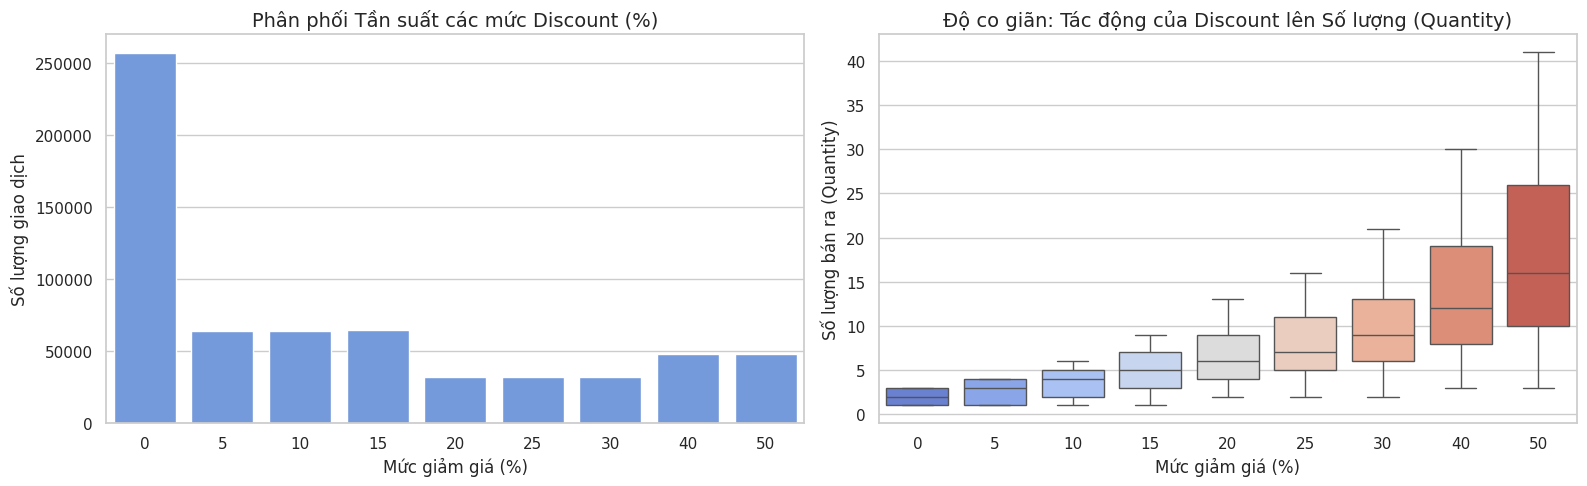

PHÂN TÍCH XU HƯỚNG BÁN HÀNG THEO THỜI GIAN


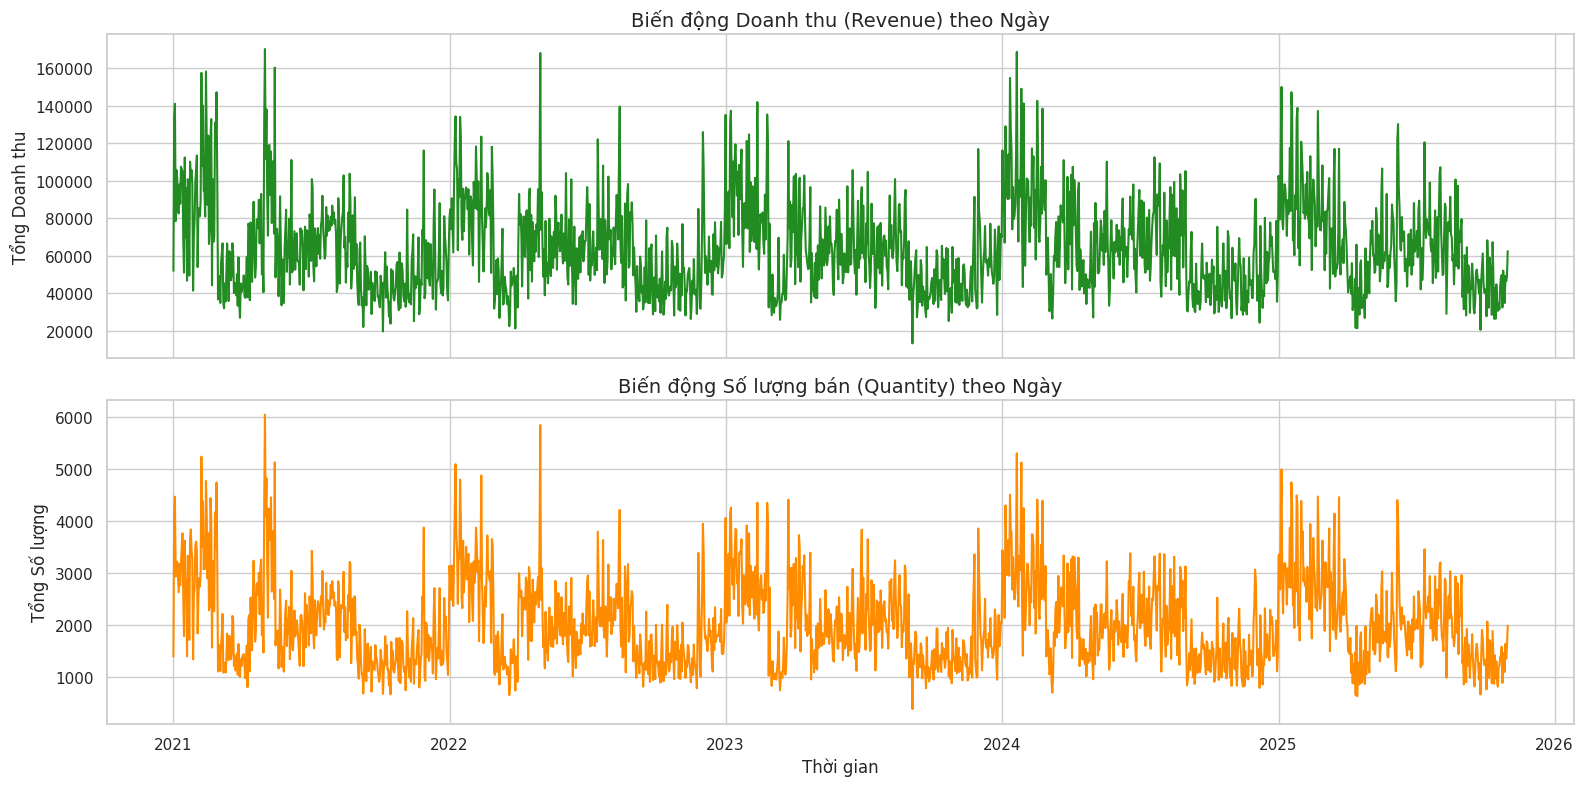

KIỂM TRA CẤU TRÚC LỢI NHUẬN GỘP (GROSS MARGIN CHECK)
Tổng số giao dịch phân tích: 641,843
Số giao dịch bán lỗ (Profit < 0): 137,431 (21.41%)
=> Chú ý: Các giao dịch bán lỗ thường xảy ra khi áp dụng mức giảm giá quá sâu (ví dụ: 40%, 50%).
=> Thuật toán Tối ưu hóa (Optimization) của chúng ta sẽ đóng vai trò tìm điểm phanh lại để chặn khoản lỗ này.


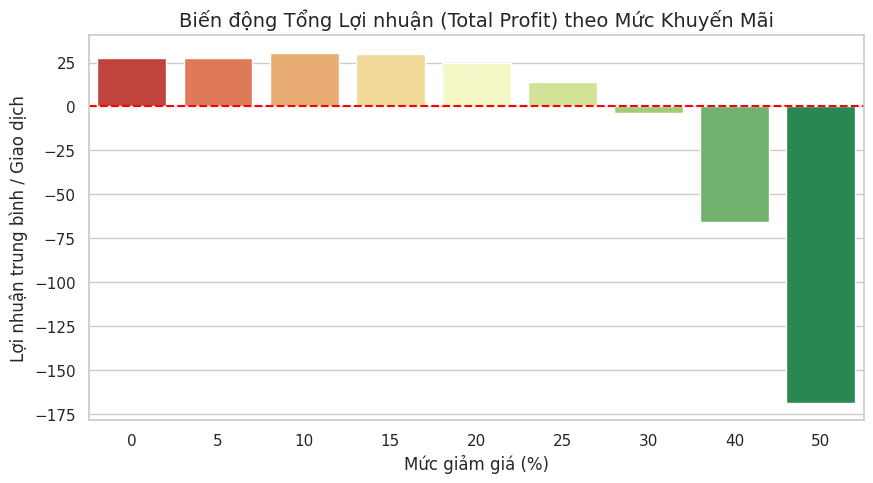


PHÂN TÍCH PARETO: ĐÓNG GÓP DOANH THU THEO SKU


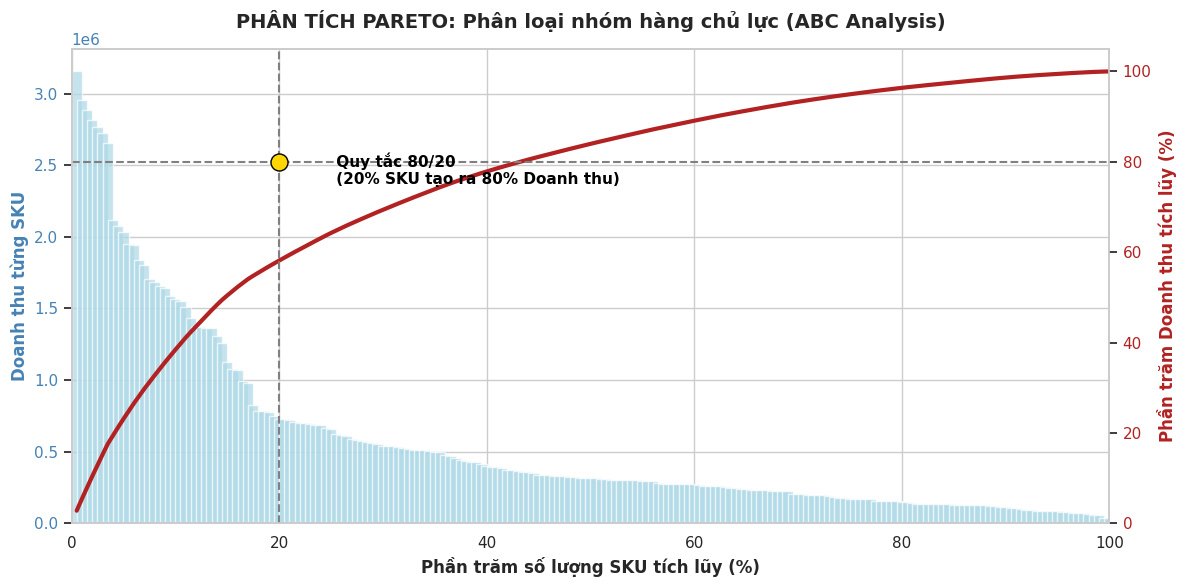


PHÂN TÍCH ĐỘ NHẠY GIÁ & SỨC BẬT KHUYẾN MÃI THEO NGÀNH HÀNG


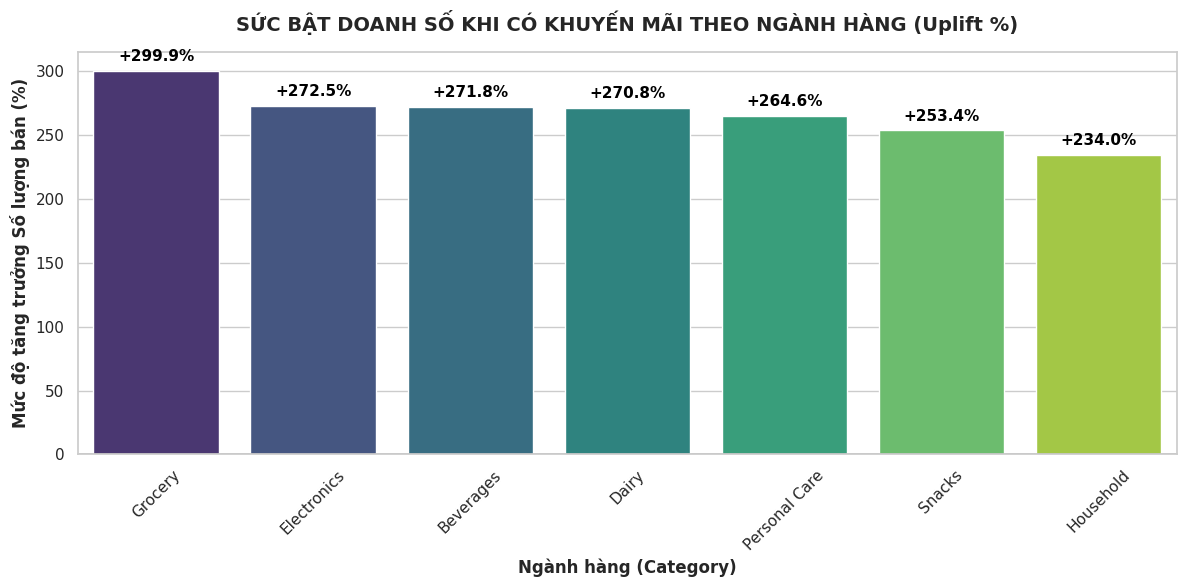

=> INSIGHT: Sự chênh lệch tỷ lệ Uplift chứng tỏ khách hàng có 'khẩu vị' nhạy cảm giá khác nhau tùy mặt hàng. Do đó, việc áp dụng 1 mức Discount chung cho toàn siêu thị là sai lầm. Cần sử dụng thuật toán AI để tìm mức Discount tối ưu (May đo) cho từng SKU.


In [ ]:
# -- 2.1 Tổng quan, missing & Duplicate
def data_overview(df_dict):
    print("TỔNG QUAN KÍCH THƯỚC & DỮ LIỆU THIẾU (MISSING VALUES)")
    summary = []
    for name, df in df_dict.items():
        missing_pct = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
        summary.append({
            "Bảng": name,
            "Số dòng": df.shape[0],
            "Số cột": df.shape[1],
            "Dòng trùng lặp": df.duplicated().sum(),
            "% Dữ liệu thiếu": f"{missing_pct:.2f}%"
        })
    display(pd.DataFrame(summary))

data_overview({
    "Sales (Synthetic)": df_sales,
    "Inventory (Synthetic)": df_inventory,
    "SKUs": df_skus,
    "Stores": df_stores,
    "Customers": df_customers,
    "Promotion": df_promotions
})

# -- 2.2. Hành vi, khuyến mãi và độ co giãn cầu
print("\n" + "="*80)
print("PHÂN TÍCH HIỆU QUẢ KHUYẾN MÃI (DISCOUNT VS QUANTITY)")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Biểu đồ phân phối các mức discount hiện tại
sns.countplot(data=df_sales, x='discount_pct', ax=axes[0], color='cornflowerblue')
axes[0].set_title("Phân phối Tần suất các mức Discount (%)")
axes[0].set_xlabel("Mức giảm giá (%)")
axes[0].set_ylabel("Số lượng giao dịch")

# Biểu đồ tác động của Discount lên Số lượng bán ra
sns.boxplot(data=df_sales, x='discount_pct', y='quantity', ax=axes[1], palette="coolwarm")
axes[1].set_title("Độ co giãn: Tác động của Discount lên Số lượng (Quantity)")
axes[1].set_xlabel("Mức giảm giá (%)")
axes[1].set_ylabel("Số lượng bán ra (Quantity)")

plt.tight_layout()
plt.show()

# -- 2.3. Phân tích xu hướng thời gian
print("PHÂN TÍCH XU HƯỚNG BÁN HÀNG THEO THỜI GIAN")

# Tổng hợp doanh thu và số lượng theo ngày
daily_sales = df_sales.groupby('date').agg(
    total_revenue=('total_value', 'sum'),
    total_quantity=('quantity', 'sum')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Trend Doanh thu
axes[0].plot(daily_sales['date'], daily_sales['total_revenue'], color='forestgreen', linewidth=1.5)
axes[0].set_title("Biến động Doanh thu (Revenue) theo Ngày", fontsize=14)
axes[0].set_ylabel("Tổng Doanh thu")

# Trend Số lượng
axes[1].plot(daily_sales['date'], daily_sales['total_quantity'], color='darkorange', linewidth=1.5)
axes[1].set_title("Biến động Số lượng bán (Quantity) theo Ngày", fontsize=14)
axes[1].set_ylabel("Tổng Số lượng")
axes[1].set_xlabel("Thời gian")

plt.tight_layout()
plt.show()


# -- 2.4. Kiểm tra lợi nhuận gộp
print("KIỂM TRA CẤU TRÚC LỢI NHUẬN GỘP (GROSS MARGIN CHECK)")

# Merge Sales với SKUs để lấy cost_price
df_eda_profit = df_sales.merge(df_skus[['sku_id', 'cost_price']], on='sku_id', how='left')

# Tính toán giá thực tế khách trả (Net Price) và Lợi nhuận (Profit)
df_eda_profit['net_price'] = df_eda_profit['total_value'] / df_eda_profit['quantity']
df_eda_profit['unit_profit'] = df_eda_profit['net_price'] - df_eda_profit['cost_price']
df_eda_profit['total_profit'] = df_eda_profit['unit_profit'] * df_eda_profit['quantity']

# Đánh giá xem có bao nhiêu giao dịch bị bán lỗ (bán dưới giá vốn)
loss_transactions = df_eda_profit[df_eda_profit['total_profit'] < 0]
loss_pct = (len(loss_transactions) / len(df_eda_profit)) * 100

print(f"Tổng số giao dịch phân tích: {len(df_eda_profit):,}")
print(f"Số giao dịch bán lỗ (Profit < 0): {len(loss_transactions):,} ({loss_pct:.2f}%)")

if loss_pct > 0:
    print("=> Chú ý: Các giao dịch bán lỗ thường xảy ra khi áp dụng mức giảm giá quá sâu (ví dụ: 40%, 50%).")
    print("=> Thuật toán Tối ưu hóa (Optimization) của chúng ta sẽ đóng vai trò tìm điểm phanh lại để chặn khoản lỗ này.")

# Vẽ Boxplot kiểm tra Margin theo Discount
plt.figure(figsize=(10, 5))
sns.barplot(data=df_eda_profit, x='discount_pct', y='total_profit', errorbar=None, palette="RdYlGn")
plt.title("Biến động Tổng Lợi nhuận (Total Profit) theo Mức Khuyến Mãi")
plt.xlabel("Mức giảm giá (%)")
plt.ylabel("Lợi nhuận trung bình / Giao dịch")
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.show()


# -- 2.5. PHÂN TÍCH PARETO
print("\nPHÂN TÍCH PARETO: ĐÓNG GÓP DOANH THU THEO SKU")

# Tính tổng doanh thu cho từng SKU
sku_revenue = df_sales.groupby('sku_id')['total_value'].sum().reset_index()
sku_revenue = sku_revenue.sort_values(by='total_value', ascending=False)

# Tính phần trăm tích lũy
sku_revenue['cum_revenue'] = sku_revenue['total_value'].cumsum()
sku_revenue['cum_revenue_pct'] = (sku_revenue['cum_revenue'] / sku_revenue['total_value'].sum()) * 100

# Tạo trục X là % số lượng SKU
sku_revenue['sku_pct'] = (np.arange(1, len(sku_revenue) + 1) / len(sku_revenue)) * 100

# Trực quan hóa
fig, ax1 = plt.subplots(figsize=(12, 6))

# Cột doanh thu của từng SKU (màu xanh nhạt)
ax1.bar(sku_revenue['sku_pct'], sku_revenue['total_value'], color='lightblue', alpha=0.7, width=1.0)
ax1.set_xlabel('Phần trăm số lượng SKU tích lũy (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Doanh thu từng SKU', color='steelblue', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Đường tích lũy phần trăm doanh thu (màu đỏ)
ax2 = ax1.twinx()
ax2.plot(sku_revenue['sku_pct'], sku_revenue['cum_revenue_pct'], color='firebrick', linewidth=3)
ax2.set_ylabel('Phần trăm Doanh thu tích lũy (%)', color='firebrick', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='firebrick')

# Vẽ đường cắt 80/20
ax2.axhline(y=80, color='gray', linestyle='--', linewidth=1.5)
ax2.axvline(x=20, color='gray', linestyle='--', linewidth=1.5)
ax2.scatter(20, 80, color='gold', s=150, edgecolor='black', zorder=5)
ax2.annotate(' Quy tắc 80/20\n (20% SKU tạo ra 80% Doanh thu)', xy=(20, 80), xytext=(25, 75),
             fontsize=11, fontweight='bold', color='black')

plt.title('PHÂN TÍCH PARETO: Phân loại nhóm hàng chủ lực (ABC Analysis)', fontsize=14, fontweight='bold', pad=15)
plt.xlim(0, 100)
plt.ylim(0, 105)
plt.grid(False)
plt.tight_layout()
plt.show()


# ***3. CLEAN & PREPARING DATA FOR MODEL***

In [ ]:
# -- 3.1. Làm sạch dữ liệu
print(f"Kích thước bảng Sales ban đầu: {df_sales.shape}")

# Xóa Duplicate
df_sales = df_sales.drop_duplicates()

# Fill NA cho customer_id
df_sales['customer_id'] = df_sales['customer_id'].fillna(0).astype(int)

print(f"Kích thước bảng Sales sau khi Clean và xóa Dup: {df_sales.shape}")

# -- 3.2. Aggeration theo tuần - giảm nhiễu hơn khi theo dạng ngày
df_sales['week'] = df_sales['date'].dt.to_period("W").apply(lambda r: r.start_time)

weekly = (
    df_sales
    .groupby(["week", "store_id", "sku_id"], as_index=False)
    .agg({
        "quantity": "sum",
        "total_value": "sum",
        "discount_pct": "mean" # Lấy mức giảm giá trung bình trong tuần
    })
)

# Sắp xếp
weekly = weekly.sort_values(["store_id", "sku_id", "week"]).reset_index(drop=True)

# Lọc bỏ các cặp Store-SKU có ít hơn 20 tuần dữ liệu
pair_count = weekly.groupby(["store_id", "sku_id"])["quantity"].count().reset_index(name="n_obs")
valid_pairs = pair_count[pair_count["n_obs"] >= 20]
weekly = weekly.merge(valid_pairs[["store_id", "sku_id"]], on=["store_id", "sku_id"], how="inner")

# Tính net price - giá bán thực tế
weekly["net_price"] = weekly["total_value"] / weekly["quantity"]

print(f"Kích thước bảng weekly sau khi gom nhóm: {weekly.shape}")

# -- 3.3. Tạo biến thời gian
weekly["weekofyear"] = weekly["week"].dt.isocalendar().week.astype(int)
weekly["month"] = weekly["week"].dt.month
weekly["quarter"] = weekly["week"].dt.quarter

# -- 3.4. Tạo biến lag & rolling
# Tạo Lag
for lag in [1, 2, 4]:
    weekly[f"lag_{lag}"] = weekly.groupby(["store_id", "sku_id"])["quantity"].shift(lag)

# -- 3.5. Tạo Rolling Mean
for w in [2, 4]:
    weekly[f"rolling_mean_{w}"] = (
        weekly.groupby(["store_id", "sku_id"])["quantity"]
        .shift(1)
        .rolling(w).mean()
    )

# -- 3.6. Tạo biến sức mua tổng thể, store và theo SKU
# Sức mua tổng của cả Store
store_weekly = weekly.groupby(["store_id", "week"], as_index=False)["quantity"].sum()
store_weekly["store_weekly_sales"] = store_weekly.groupby("store_id")["quantity"].shift(1)

# Sức độ hot tổng của SKU
sku_weekly = weekly.groupby(["sku_id", "week"], as_index=False)["quantity"].sum()
sku_weekly["sku_weekly_sales"] = sku_weekly.groupby("sku_id")["quantity"].shift(1)

# Ghép ngược lại vào bảng chính
weekly = weekly.merge(store_weekly[["store_id", "week", "store_weekly_sales"]], on=["store_id", "week"], how="left")
weekly = weekly.merge(sku_weekly[["sku_id", "week", "sku_weekly_sales"]], on=["sku_id", "week"], how="left")

# 3.7. Xử lý biến mục tiêu và làm sạch
# Log transform các biến Quantity để giảm độ lệch
weekly["log_quantity"] = np.log1p(weekly["quantity"])
weekly["store_weekly_sales"] = np.log1p(weekly["store_weekly_sales"])
weekly["sku_weekly_sales"] = np.log1p(weekly["sku_weekly_sales"])

# Merge thêm cost price từ bảng SKUs
weekly = weekly.merge(df_skus[["sku_id", "cost_price"]], on="sku_id", how="left")
weekly['cost_price'] = weekly['cost_price'].fillna(0)

# Xóa các dòng bị thiếu dữ liệu do quá trình tạo Lag/Rolling
weekly = weekly.dropna().reset_index(drop=True)

print(f"Kích thước bảng Weekly sau khi làm sạch (Sẵn sàng cho Model): {weekly.shape}")
display(weekly)

Kích thước bảng Sales ban đầu: (641843, 9)
Kích thước bảng Sales sau khi Clean và xóa Dup: (641830, 9)
Kích thước bảng weekly sau khi gom nhóm: (563428, 7)
Kích thước bảng Weekly sau khi làm sạch (Sẵn sàng cho Model): (523428, 19)


,week,store_id,sku_id,quantity,total_value,discount_pct,net_price,weekofyear,month,quarter,lag_1,lag_2,lag_4,rolling_mean_2,rolling_mean_4,store_weekly_sales,sku_weekly_sales,log_quantity,cost_price
0,2021-05-10,1,1001,1,123.4200,0.0,123.4200,19,5,2,20.0,3.0,5.0,11.5,7.75,6.253829,5.389072,0.693147,103.44
1,2021-06-07,1,1001,3,394.9440,20.0,131.6480,23,6,2,1.0,20.0,3.0,10.5,6.75,5.863631,4.795791,1.386294,103.44
2,2021-06-21,1,1001,3,493.6800,0.0,164.5600,25,6,2,3.0,1.0,3.0,2.0,6.75,5.697093,4.369448,1.386294,103.44
3,2021-09-13,1,1001,7,979.1320,15.0,139.8760,37,9,3,3.0,3.0,20.0,3.0,6.75,5.209486,3.401197,2.079442,103.44
4,2021-09-20,1,1001,8,987.3600,25.0,123.4200,38,9,3,7.0,3.0,1.0,5.0,3.50,5.488938,3.761200,2.197225,103.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
523423,2025-06-16,50,1200,5,28.0875,25.0,5.6175,25,6,2,12.0,19.0,2.0,15.5,9.00,5.746203,4.595120,1.791759,5.50
523424,2025-06-30,50,1200,9,57.2985,15.0,6.3665,27,6,2,5.0,12.0,3.0,8.5,9.75,5.575949,4.804021,2.302585,5.50
523425,2025-08-11,50,1200,13,68.1590,30.0,5.2430,33,8,3,9.0,5.0,19.0,7.0,11.25,5.204007,4.262680,2.639057,5.50
523426,2025-09-22,50,1200,2,14.9800,0.0,7.4900,39,9,3,13.0,9.0,12.0,11.0,9.75,5.220356,3.178054,1.098612,5.50


In [ ]:
# -- 3.8. Chia tập train/test theo time và chọn biến
# Xác định ngày chia cắt (80% thời gian đầu cho Train, 20% thời gian sau cho Test)
split_date = weekly["week"].quantile(0.8)

train = weekly[weekly["week"] < split_date].copy()
test  = weekly[weekly["week"] >= split_date].copy()

print(f"Ngày cắt (Split Date) : {split_date}")
print(f"Kích thước tập Train  : {train.shape[0]:,} dòng")
print(f"Kích thước tập Test   : {test.shape[0]:,} dòng")

# Định nghĩa Features và Target
features = [
    "store_id", "sku_id", "discount_pct", "weekofyear", "month",
    "quarter", "lag_1", "lag_2", "lag_4", "rolling_mean_2",
    "rolling_mean_4", "store_weekly_sales", "sku_weekly_sales"
]
target = "log_quantity"

Ngày cắt (Split Date) : 2024-12-09 00:00:00
Kích thước tập Train  : 417,498 dòng
Kích thước tập Test   : 105,930 dòng


# ***4. MODELING***

## ***4.1. BENCHMARKING***

Đang huấn luyện và dự báo: 1. Baseline (Naive Lag 1)...
Đang huấn luyện và dự báo: 2. Ridge Regression...
Đang huấn luyện và dự báo: 3. Random Forest...
Đang huấn luyện và dự báo: 4. XGBoost...
Đang huấn luyện và dự báo: 5. LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016468 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1318
[LightGBM] [Info] Number of data points in the train set: 417498, number of used features: 13
[LightGBM] [Info] Start training from score 1.682827

Đã chạy xong tất cả các mô hình!


,Model,WAPE,MAE,RMSE
0,5. LightGBM,0.3787,2.4325,4.2398
1,4. XGBoost,0.3876,2.4897,4.3834
2,3. Random Forest,0.4000,2.5691,4.5314
3,2. Ridge Regression,0.4466,2.8685,5.1210
4,1. Baseline (Naive Lag 1),0.9822,6.3085,9.9424


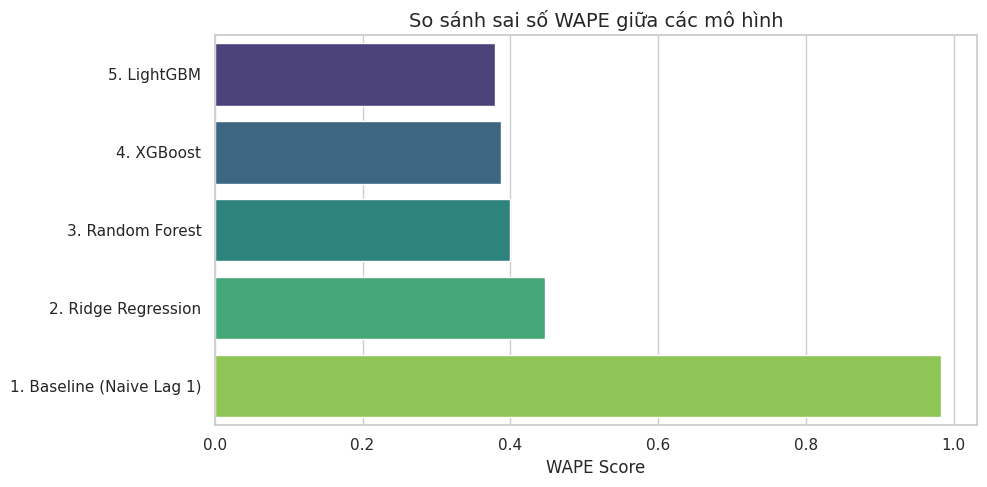

In [ ]:
# -- 4.1.1. Khởi tạo danh sách các mô hình
models = {
    "1. Baseline (Naive Lag 1)": "naive",
    "2. Ridge Regression": Ridge(random_state=42),
    "3. Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "4. XGBoost": xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1),
    "5. LightGBM": lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=64, random_state=42, n_jobs=-1)
}

results = []

for name, model in models.items():
    print(f"Đang huấn luyện và dự báo: {name}...")

    if name == "1. Baseline (Naive Lag 1)":
        pred_qty = test["lag_1"].values
    else:
        model.fit(train[features], train[target])
        pred_log = model.predict(test[features])
        pred_qty = np.expm1(pred_log)
    pred_qty = np.clip(pred_qty, 0, None) # Tránh dự báo số âm

    # Tính toán Metrics
    mae = mean_absolute_error(test["quantity"], pred_qty)
    rmse = np.sqrt(mean_squared_error(test["quantity"], pred_qty))
    wape = np.sum(np.abs(test["quantity"] - pred_qty)) / np.sum(test["quantity"])

    results.append({
        "Model": name,
        "WAPE": wape,
        "MAE": mae,
        "RMSE": rmse
    })

print("\nĐã chạy xong tất cả các mô hình!")

# -- 4.1.2. Trực quan hóa kết quả
df_results = pd.DataFrame(results).sort_values("WAPE").reset_index(drop=True)

# Hiển thị bảng dạng format đẹp
display(df_results.style.format({
    "WAPE": "{:.4f}",
    "MAE": "{:.4f}",
    "RMSE": "{:.4f}"
}).background_gradient(subset=["WAPE"], cmap="Greens_r"))

# Vẽ biểu đồ so sánh WAPE, càng thấp càng tốt
plt.figure(figsize=(10, 5))
sns.barplot(data=df_results, x="WAPE", y="Model", palette="viridis")
plt.title("So sánh sai số WAPE giữa các mô hình")
plt.xlabel("WAPE Score")
plt.ylabel("")
plt.tight_layout()
plt.show()

## ***4.2. HYPERPARAMETER TUNING***

In [ ]:
# -- 4.2.1. Thiết lập Ràng buộc đơn điệu - Vị trí số "1" trong list tương đương với vị trí "discount" và 1 có nghĩa là đồng biến (Tăng discount -> Tăng Quantity)
constraints = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

# -- 4.2.2. Tối ưu tham số
def objective(trial):
    param = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'n_estimators': 300, # Giảm xuống 300 lúc tuning cho nhanh
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 31, 128),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'monotone_constraints': constraints # Đã có biến constraints ở trên
    }

    # Train nhanh trên tập Train/Test đã chia (đảm bảo biến train và test đã có trong RAM)
    model = lgb.LGBMRegressor(**param, n_jobs=-1)
    model.fit(train[features], train[target])

    # Dự báo và tính sai số
    preds = model.predict(test[features])
    rmse = np.sqrt(mean_squared_error(test[target], preds))
    return rmse

optuna.logging.set_verbosity(optuna.logging.WARNING)

print("[*] Đang chạy 20 vòng lặp thử nghiệm. Vui lòng đợi trong giây lát...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

best_params = study.best_params
best_params['monotone_constraints'] = constraints
best_params['random_state'] = 42

print("\n[✔] TÌM THẤY BỘ THAM SỐ TỐI ƯU NHẤT:")
for key, value in best_params.items():
    if key != 'monotone_constraints':
        print(f"    - {key}: {value}")

""" BỘ THAM SỐ TỐI ƯU NHẤT:
    - learning_rate: 0.07207090555536025
    - num_leaves: 98
    - subsample: 0.6243736736467822
    - colsample_bytree: 0.8867139550477205
    - min_child_samples: 72
    - random_state: 42
"""

[*] Đang chạy 20 vòng lặp thử nghiệm. Vui lòng đợi trong giây lát...

[✔] TÌM THẤY BỘ THAM SỐ TỐI ƯU NHẤT:
    - learning_rate: 0.09246761577025628
    - num_leaves: 128
    - subsample: 0.6446916284298634
    - colsample_bytree: 0.8426278954197318
    - min_child_samples: 44
    - random_state: 42


' BỘ THAM SỐ TỐI ƯU NHẤT:\n    - learning_rate: 0.07207090555536025\n    - num_leaves: 98\n    - subsample: 0.6243736736467822\n    - colsample_bytree: 0.8867139550477205\n    - min_child_samples: 72\n    - random_state: 42\n'

## ***4.3. MAIN MODEL - LIGHTGBM***

Đang huấn luyện mô hình...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.053264 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1318
[LightGBM] [Info] Number of data points in the train set: 417498, number of used features: 13
[LightGBM] [Info] Start training from score 1.682827

Huấn luyện hoàn tất
KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH LIGHTGBM:
- WAPE: 0.3970
- MAE:  2.5499
- RMSE: 4.5163
BIỂU ĐỒ SHAP EXPLANATION


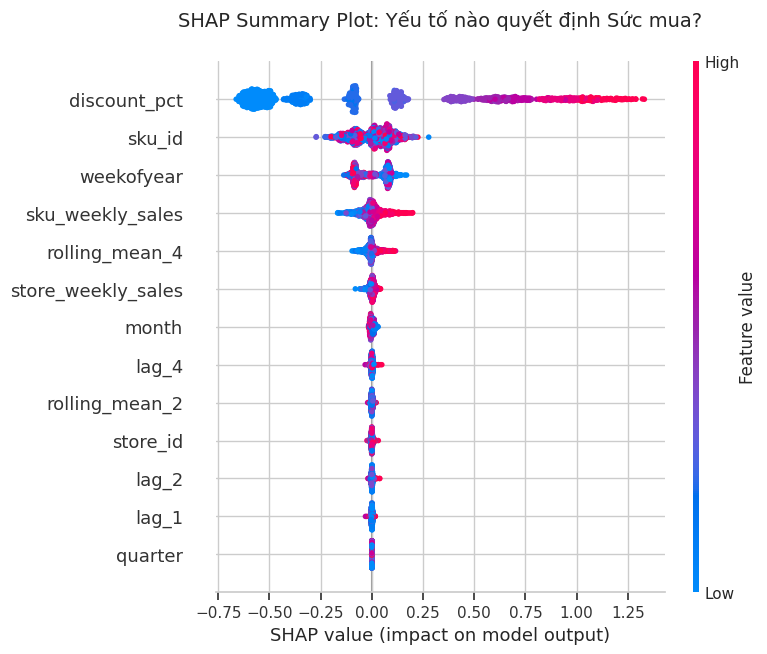

<Figure size 800x500 with 0 Axes>

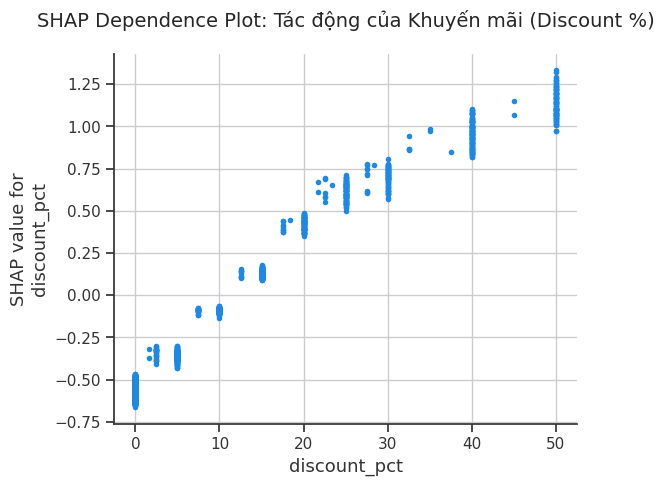

[✔] Đã lưu mô hình tối ưu tại: /content/drive/Shareddrives/PTDL NANG CAO - NHOM 10/ĐỒ ÁN CUỐI KỲ/data_2/final_lightgbm_optimized.pkl
[✔] Đã lưu dữ liệu sạch tại: /content/drive/Shareddrives/PTDL NANG CAO - NHOM 10/ĐỒ ÁN CUỐI KỲ/data_2/weekly_clean_for_app.csv


In [ ]:
# -- 4.2.1. -- Bỏ phần khởi tạo constraints này nếu có chạy phần Optuna ở trên
constraints = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
# Khởi tạo mô hình - từ chỉ số tốt nhất ở trên
final_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.072,
    num_leaves=98,
    subsample=0.624,
    colsample_bytree=0.887,      # Làm tròn 0.8867
    min_child_samples=72,        # Tham số quan trọng chống học vẹt (Overfitting)
    random_state=42,
    monotone_constraints=constraints,
    monotone_constraints_method='advanced',
    n_jobs=-1
)

print("Đang huấn luyện mô hình...")
final_model.fit(
    train[features], train[target],
    eval_set=[(test[features], test[target])],
    eval_metric="l1",
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

print("\nHuấn luyện hoàn tất")


# -- 4.3.2. Dự báo trên tập Test ban đầu
test["pred_log_final"] = final_model.predict(test[features])
test["pred_qty_final"] = np.expm1(test["pred_log_final"])
test["pred_qty_final"] = np.clip(test["pred_qty_final"], 0, None)

mae_final = mean_absolute_error(test["quantity"], test["pred_qty_final"])
rmse_final = np.sqrt(mean_squared_error(test["quantity"], test["pred_qty_final"]))
wape_final = np.sum(np.abs(test["quantity"] - test["pred_qty_final"])) / np.sum(test["quantity"])

print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH LIGHTGBM:")
print(f"- WAPE: {wape_final:.4f}")
print(f"- MAE:  {mae_final:.4f}")
print(f"- RMSE: {rmse_final:.4f}")

# -- 4.3.3. Phân tích SHAP
print("BIỂU ĐỒ SHAP EXPLANATION")

# Lấy một mẫu ngẫu nhiên từ tập Test để tính SHAP cho nhanh
X_explain = test[features].sample(1500, random_state=42)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_explain)

# Biểu đồ 1: SHAP Summary Plot (Mức độ quan trọng của các biến)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_explain, show=False)
plt.title("SHAP Summary Plot: Yếu tố nào quyết định Sức mua?", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# Biểu đồ 2: SHAP Dependence Plot cho Khuyến mãi
plt.figure(figsize=(8, 5))
shap.dependence_plot("discount_pct", shap_values, X_explain, interaction_index=None, show=False)
plt.title("SHAP Dependence Plot: Tác động của Khuyến mãi (Discount %)", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# ==============================================================================
# LƯU MÔ HÌNH & DỮ LIỆU ĐỂ ĐƯA LÊN WEB APP (STREAMLIT)
# ==============================================================================
base_path = '/content/drive/Shareddrives/PTDL NANG CAO - NHOM 10/ĐỒ ÁN CUỐI KỲ/data_2/'

# Lưu Model
model_path = base_path + 'final_lightgbm_optimized.pkl'
joblib.dump(final_model, model_path)

# Lưu Dữ liệu Weekly (chỉ lấy những cột cần thiết cho App chạy cho nhẹ)
app_data = weekly[['week', 'store_id', 'sku_id', 'quantity', 'total_value', 'discount_pct', 'net_price', 'cost_price', 'lag_1', 'lag_2', 'lag_4', 'rolling_mean_2', 'rolling_mean_4', 'store_weekly_sales', 'sku_weekly_sales']].copy()
app_data.to_csv(base_path + 'weekly_clean_for_app.csv', index=False)

print(f"[✔] Đã lưu mô hình tối ưu tại: {model_path}")
print(f"[✔] Đã lưu dữ liệu sạch tại: {base_path}weekly_clean_for_app.csv")


In [ ]:
# ==============================================================================
# 2. FEATURE IMPORTANCE STABILITY CHECK (TIME-SERIES SPLIT)
# ==============================================================================
print("\nĐang kiểm tra tính ổn định của Feature Importance qua 5 Folds (Time-based)...")
from sklearn.model_selection import TimeSeriesSplit

importances = []

# 1. Khai báo cứng bộ tham số tốt nhất
static_params = {
    'learning_rate': 0.072,
    'num_leaves': 98,
    'subsample': 0.624,
    'colsample_bytree': 0.887,
    'min_child_samples': 72,
    'random_state': 42,
    'monotone_constraints': constraints,
    'monotone_constraints_method': 'advanced'
}

# Đảm bảo dữ liệu được sắp xếp chuẩn theo thời gian trước khi chia
df_train_sorted = train.sort_values(['week', 'store_id', 'sku_id']).reset_index(drop=True)

# 2. Sử dụng TimeSeriesSplit để cắt dữ liệu tịnh tiến theo thời gian (Không xáo trộn ngẫu nhiên)
tscv = TimeSeriesSplit(n_splits=5)

fold = 1
for train_idx, val_idx in tscv.split(df_train_sorted):
    # Lấy tập dữ liệu huấn luyện cho Fold hiện tại (Thời gian tăng dần qua từng Fold)
    df_sub = df_train_sorted.iloc[train_idx]

    m = lgb.LGBMRegressor(**static_params, n_estimators=200, verbose=-1, n_jobs=-1)
    m.fit(df_sub[features], df_sub[target])

    importances.append(m.feature_importances_)
    print(f" - Fold {fold}: Đã huấn luyện trên {len(df_sub):,} dòng (dữ liệu từ tuần đầu đến mốc thời gian {fold})")
    fold += 1

# 3. Tính trung bình và độ lệch chuẩn của Importance
imp_df = pd.DataFrame(importances, columns=features)
stability_summary = pd.DataFrame({
    'Feature': features,
    'Mean_Importance': imp_df.mean(),
    'Std_Dev': imp_df.std()
}).sort_values('Mean_Importance', ascending=False)

print("\nKẾT QUẢ KIỂM ĐỊNH TÍNH ỔN ĐỊNH CỦA BIẾN (TIME-SERIES STABILITY):")
display(stability_summary.style.background_gradient(cmap='Blues'))


Đang kiểm tra tính ổn định của Feature Importance qua 5 Folds (Time-based)...
 - Fold 1: Đã huấn luyện trên 69,583 dòng (dữ liệu từ tuần đầu đến mốc thời gian 1)
 - Fold 2: Đã huấn luyện trên 139,166 dòng (dữ liệu từ tuần đầu đến mốc thời gian 2)
 - Fold 3: Đã huấn luyện trên 208,749 dòng (dữ liệu từ tuần đầu đến mốc thời gian 3)
 - Fold 4: Đã huấn luyện trên 278,332 dòng (dữ liệu từ tuần đầu đến mốc thời gian 4)
 - Fold 5: Đã huấn luyện trên 347,915 dòng (dữ liệu từ tuần đầu đến mốc thời gian 5)

KẾT QUẢ KIỂM ĐỊNH TÍNH ỔN ĐỊNH CỦA BIẾN (TIME-SERIES STABILITY):


,Feature,Mean_Importance,Std_Dev
sku_id,sku_id,5215.600000,817.992543
sku_weekly_sales,sku_weekly_sales,2725.800000,82.581475
weekofyear,weekofyear,2036.000000,87.306930
rolling_mean_4,rolling_mean_4,1964.800000,74.004730
store_weekly_sales,store_weekly_sales,1923.000000,172.521013
store_id,store_id,1323.200000,226.753611
rolling_mean_2,rolling_mean_2,915.600000,101.559342
lag_4,lag_4,892.400000,103.188178
lag_2,lag_2,782.800000,103.911982
lag_1,lag_1,763.600000,113.445141


## ***4.4. WALK-FORWARD VALIDATION***

,Fold,Test_Period,Train_Weeks,Test_Weeks,WAPE
0,Fold 1,2024-01-01 to 2024-06-10,153,24,0.3988
1,Fold 2,2024-06-17 to 2024-11-25,177,24,0.4006
2,Fold 3,2024-12-02 to 2025-05-12,201,24,0.3969
3,Fold 4,2025-05-19 to 2025-10-27,225,24,0.4052



=> WAPE Trung bình (Walk-forward): 0.4004
=> KẾT LUẬN: Mô hình cực kỳ ổn định, không bị overfit

 Đã tạo xong bảng dữ liệu tài chính (wf_df). Bắt đầu vẽ biểu đồ...


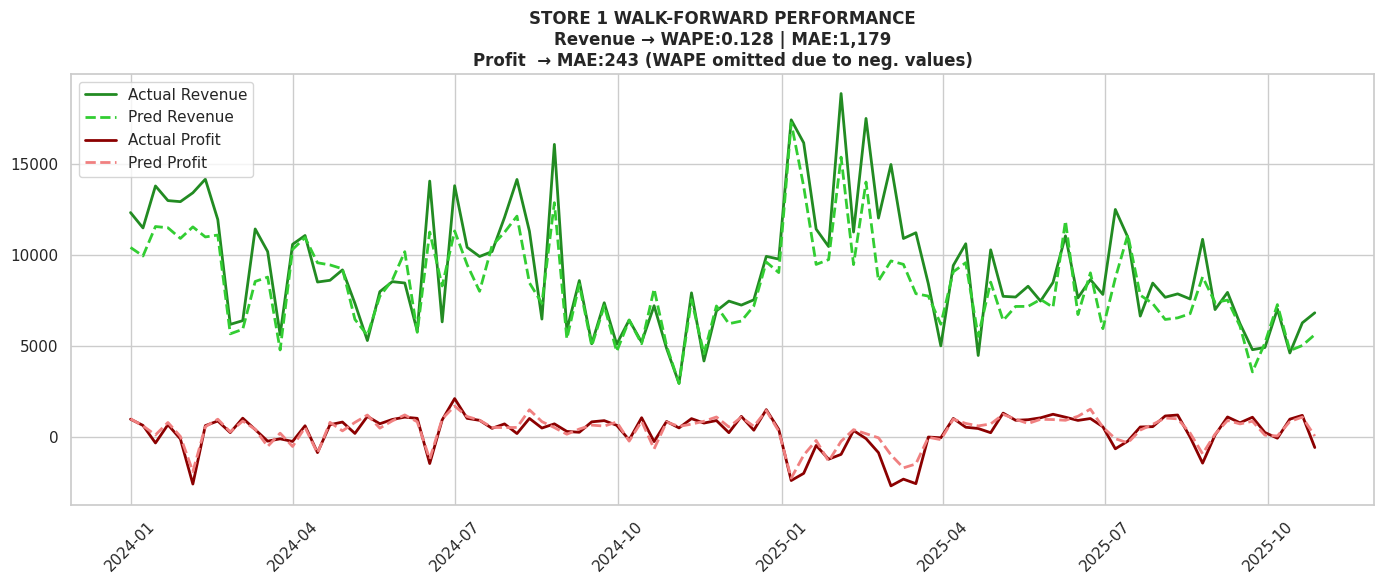

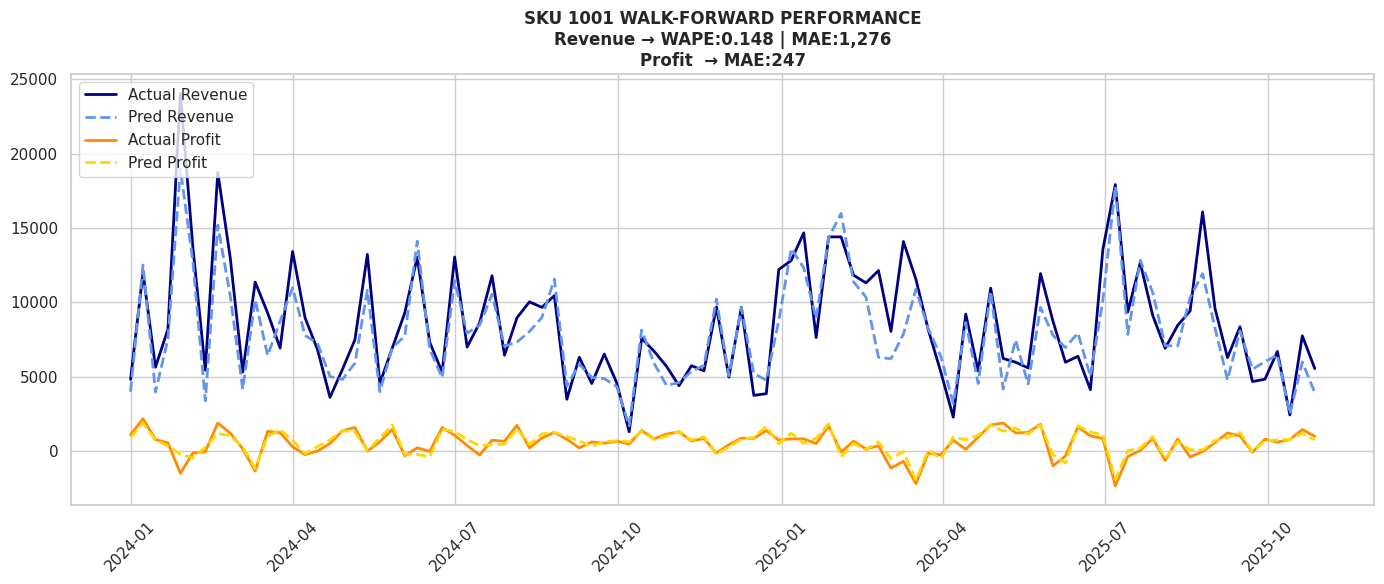

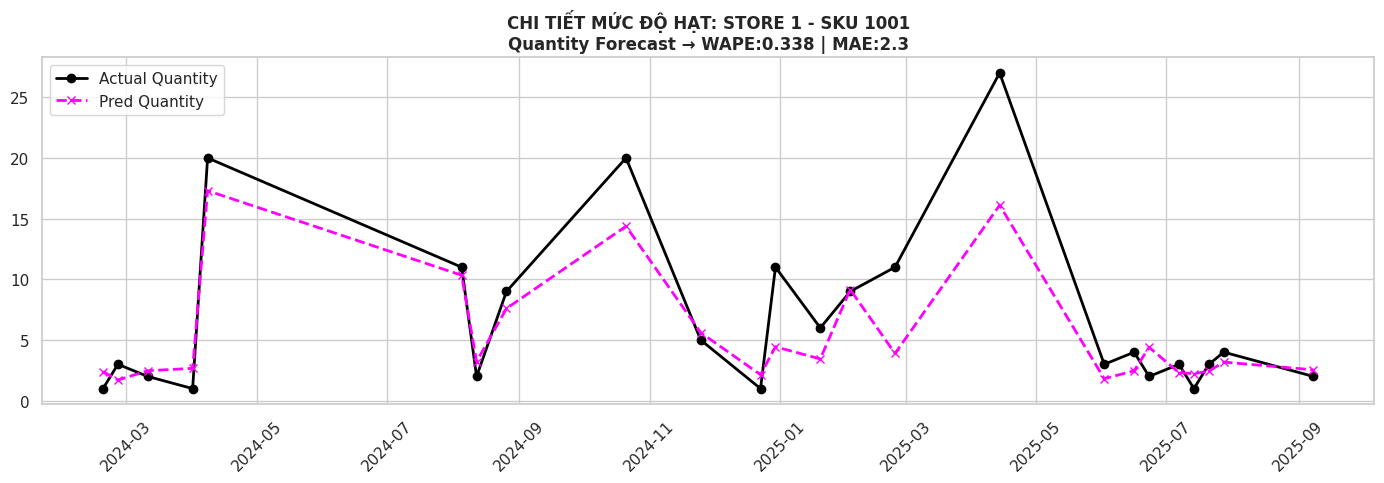

In [ ]:
# -- 4.4.1. Walk-forward
# Khởi tạo thông số cho Walk-Forward
unique_weeks = np.sort(weekly["week"].unique())
n_splits = 4 # 4 giai đoạn thời gian liên tiếp
test_size = len(unique_weeks) // 10

wf_results = []
all_predictions = [] # Danh sách lưu dữ liệu dự báo chi tiết

# Vòng lặp đánh giá và lưu dữ liệu
for i in range(n_splits, 0, -1):
    test_start_idx = len(unique_weeks) - (i * test_size)
    test_end_idx = test_start_idx + test_size

    train_weeks = unique_weeks[:test_start_idx]
    test_weeks = unique_weeks[test_start_idx:test_end_idx]

    train_wf = weekly[weekly["week"].isin(train_weeks)]
    test_wf = weekly[weekly["week"].isin(test_weeks)].copy()

    # Khởi tạo và train mô hình
    model_wf = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, num_leaves=64,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        monotone_constraints=constraints, monotone_constraints_method='advanced', n_jobs=-1
    )
    model_wf.fit(train_wf[features], train_wf[target])

    # Dự báo
    test_wf["pred_log"] = model_wf.predict(test_wf[features])
    test_wf["pred_qty"] = np.expm1(test_wf["pred_log"])
    test_wf["pred_qty"] = np.clip(test_wf["pred_qty"], 0, None)

    # Tính WAPE cho Fold hiện tại
    wape_fold = np.sum(np.abs(test_wf["quantity"] - test_wf["pred_qty"])) / (np.sum(test_wf["quantity"]) + 1e-9)

    # Lưu kết quả tổng hợp
    start_date = pd.to_datetime(test_weeks[0]).strftime('%Y-%m-%d')
    end_date = pd.to_datetime(test_weeks[-1]).strftime('%Y-%m-%d')
    wf_results.append({
        "Fold": f"Fold {n_splits - i + 1}",
        "Test_Period": f"{start_date} to {end_date}",
        "Train_Weeks": len(train_weeks),
        "Test_Weeks": len(test_weeks),
        "WAPE": wape_fold
    })

    # Lưu dữ liệu chi tiết để vẽ biểu đồ
    test_wf["fold"] = f"Fold {n_splits - i + 1}"
    all_predictions.append(test_wf)

# -- 4.4.2. Hiển thị kết quả đánh giá
df_wf_summary = pd.DataFrame(wf_results)
display(df_wf_summary.style.format({"WAPE": "{:.4f}"}).background_gradient(subset=["WAPE"], cmap="Greens_r"))

avg_wape = df_wf_summary["WAPE"].mean()
print(f"\n=> WAPE Trung bình (Walk-forward): {avg_wape:.4f}")
if avg_wape < 0.45:
    print("=> KẾT LUẬN: Mô hình cực kỳ ổn định, không bị overfit")
else:
    print("Mô hình cần xem xét lại")


# -- 4.4.3. Tính doanh thu và lợi nhuận
wf_df = pd.concat(all_predictions, ignore_index=True)

# Actuals
wf_df["actual_revenue"] = wf_df["quantity"] * wf_df["net_price"]
wf_df["actual_profit"] = wf_df["quantity"] * (wf_df["net_price"] - wf_df["cost_price"])

# Predictions
wf_df["pred_revenue"] = wf_df["pred_qty"] * wf_df["net_price"]
wf_df["pred_profit"] = wf_df["pred_qty"] * (wf_df["net_price"] - wf_df["cost_price"])

print("\n Đã tạo xong bảng dữ liệu tài chính (wf_df). Bắt đầu vẽ biểu đồ...")

# -- 4.4.4. Trực quan hóa kết quả
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / (np.sum(y_true) + 1e-9)

sns.set_theme(style="whitegrid")

# -- 4.4.4.a. Theo store level
store_selected = 1
store_time = (
    wf_df.query("store_id == @store_selected")
    .groupby("week")[["actual_revenue","pred_revenue","actual_profit","pred_profit"]]
    .sum().reset_index()
)

store_rev_wape = wape(store_time["actual_revenue"], store_time["pred_revenue"])
store_rev_mae = mean_absolute_error(store_time["actual_revenue"], store_time["pred_revenue"])
store_profit_mae = mean_absolute_error(store_time["actual_profit"], store_time["pred_profit"])

plt.figure(figsize=(14,6))
plt.plot(store_time["week"], store_time["actual_revenue"], label="Actual Revenue", color="forestgreen", linewidth=2)
plt.plot(store_time["week"], store_time["pred_revenue"], linestyle="--", label="Pred Revenue", color="limegreen", linewidth=2)
plt.plot(store_time["week"], store_time["actual_profit"], label="Actual Profit", color="darkred", linewidth=2)
plt.plot(store_time["week"], store_time["pred_profit"], linestyle="--", label="Pred Profit", color="lightcoral", linewidth=2)

plt.xticks(rotation=45)
plt.legend(loc="upper left")
plt.title(
    f"STORE {store_selected} WALK-FORWARD PERFORMANCE\n"
    f"Revenue → WAPE:{store_rev_wape:.3f} | MAE:{store_rev_mae:,.0f}\n"
    f"Profit  → MAE:{store_profit_mae:,.0f} (WAPE omitted due to neg. values)",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

# -- 4.4.4.b. Theo SKU level
sku_selected = wf_df['sku_id'].unique()[0]
sku_time = (
    wf_df.query("sku_id == @sku_selected")
    .groupby("week")[["actual_revenue","pred_revenue","actual_profit","pred_profit"]]
    .sum().reset_index()
)

sku_rev_wape = wape(sku_time["actual_revenue"], sku_time["pred_revenue"])
sku_rev_mae = mean_absolute_error(sku_time["actual_revenue"], sku_time["pred_revenue"])
sku_profit_mae = mean_absolute_error(sku_time["actual_profit"], sku_time["pred_profit"])

plt.figure(figsize=(14,6))
plt.plot(sku_time["week"], sku_time["actual_revenue"], label="Actual Revenue", color="navy", linewidth=2)
plt.plot(sku_time["week"], sku_time["pred_revenue"], linestyle="--", label="Pred Revenue", color="cornflowerblue", linewidth=2)
plt.plot(sku_time["week"], sku_time["actual_profit"], label="Actual Profit", color="darkorange", linewidth=2)
plt.plot(sku_time["week"], sku_time["pred_profit"], linestyle="--", label="Pred Profit", color="gold", linewidth=2)

plt.xticks(rotation=45)
plt.legend(loc="upper left")
plt.title(
    f"SKU {sku_selected} WALK-FORWARD PERFORMANCE\n"
    f"Revenue → WAPE:{sku_rev_wape:.3f} | MAE:{sku_rev_mae:,.0f}\n"
    f"Profit  → MAE:{sku_profit_mae:,.0f}",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

# -- 4.4.4.c. Theo cấp độ chi tiết nhất (Store x SKU level)
store_val = 1
sku_val = wf_df['sku_id'].unique()[0] # Chọn đại 1 SKU phổ biến

# Lọc dữ liệu cho đúng cặp Store - SKU đó
granular_time = (
    wf_df.query("store_id == @store_val and sku_id == @sku_val")
    .sort_values("week")
    .reset_index(drop=True)
)

granular_wape = wape(granular_time["quantity"], granular_time["pred_qty"])
granular_mae = mean_absolute_error(granular_time["quantity"], granular_time["pred_qty"])

plt.figure(figsize=(14,5))
# Vẽ Quantity thay vì Revenue/Profit để dễ nhìn sự biến thiên
plt.plot(granular_time["week"], granular_time["quantity"], label="Actual Quantity", color="black", marker='o', linewidth=2)
plt.plot(granular_time["week"], granular_time["pred_qty"], linestyle="--", label="Pred Quantity", color="magenta", marker='x', linewidth=2)

plt.xticks(rotation=45)
plt.legend(loc="upper left")
plt.title(
    f"CHI TIẾT MỨC ĐỘ HẠT: STORE {store_val} - SKU {sku_val}\n"
    f"Quantity Forecast → WAPE:{granular_wape:.3f} | MAE:{granular_mae:.1f}",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

# ***5. What-if optimalzation***

## ***5.1. Hàm mô phỏng What-If***

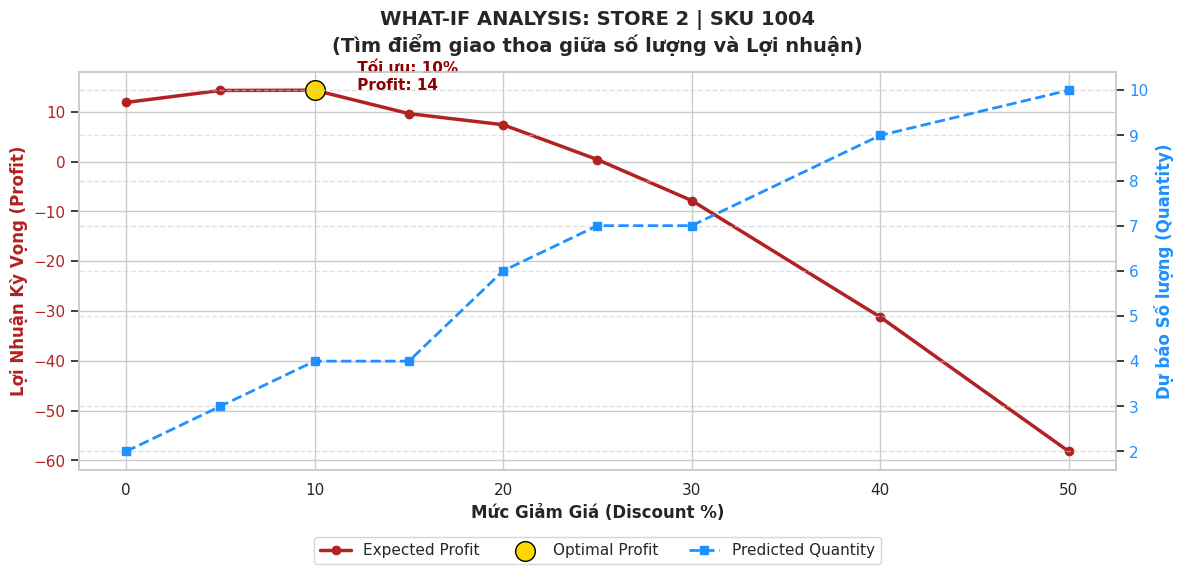


--------------------------------------------------
BẢNG KỊCH BẢN TÀI CHÍNH (STORE 2 - SKU 1004)
--------------------------------------------------


,discount_pct,sim_net_price,pred_qty,expected_revenue,expected_profit
0,0%,23.52,2,47.03,11.87
1,5%,22.34,3,67.02,14.28
2,10%,21.16,4,84.65,14.33
3,15%,19.99,4,79.95,9.63
4,20%,18.81,6,112.87,7.39
5,25%,17.64,7,123.46,0.40
6,30%,16.46,7,115.22,-7.84
7,40%,14.11,9,126.98,-31.24
8,50%,11.76,10,117.58,-58.22


In [ ]:
# -- What-if
def simulate_what_if_discount(store_id, sku_id, df_weekly, model, features):
    """
    Hàm mô phỏng các kịch bản giảm giá cho 1 Store-SKU cụ thể ở tuần gần nhất
    """
    # Lấy dữ liệu của tuần gần nhất làm điểm xuất phát
    latest_data = df_weekly[(df_weekly['store_id'] == store_id) &
                            (df_weekly['sku_id'] == sku_id)].sort_values('week').tail(1).copy()

    if latest_data.empty:
        print(f"⚠️ Không tìm thấy lịch sử bán hàng cho Store {store_id} - SKU {sku_id}")
        return None

    # Phục hồi giá gốc trước khi có khuyến mãi cũ
    old_net_price = latest_data['net_price'].values[0]
    old_discount = latest_data['discount_pct'].values[0]
    cost_price = latest_data['cost_price'].values[0]

    # Tránh lỗi chia cho 0 nếu old_discount = 100%
    base_price = old_net_price / (1 - old_discount/100) if old_discount != 100 else old_net_price

    # Tạo các kịch bản giảm giá
    test_discounts = [0, 5, 10, 15, 20, 25, 30, 40, 50]
    results = []

    # Chuẩn bị 1 bảng copy của dòng dữ liệu hiện tại để chạy vòng lặp
    sim_df = pd.concat([latest_data]*len(test_discounts), ignore_index=True)
    sim_df['discount_pct'] = test_discounts

    # Dự báo toàn bộ kịch bản
    pred_log = model.predict(sim_df[features])
    sim_df['pred_qty'] = np.expm1(pred_log)
    sim_df['pred_qty'] = np.clip(np.round(sim_df['pred_qty']), 0, None) # Làm tròn số lượng

    # Tính doanh thu và lợi nhuận
    sim_df['sim_net_price'] = base_price * (1 - sim_df['discount_pct'] / 100.0)
    sim_df['expected_revenue'] = sim_df['pred_qty'] * sim_df['sim_net_price']
    sim_df['expected_profit'] = sim_df['pred_qty'] * (sim_df['sim_net_price'] - cost_price)

    final_results = sim_df[['discount_pct', 'sim_net_price', 'pred_qty', 'expected_revenue', 'expected_profit']]

    # Tìm điểm tối ưu Lợi Nhuận
    best_idx = final_results['expected_profit'].idxmax()
    best_discount = final_results.loc[best_idx, 'discount_pct']
    best_profit = final_results.loc[best_idx, 'expected_profit']
    best_qty = final_results.loc[best_idx, 'pred_qty']

# -- Trực quan hóa kết quả
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Đường lợi nhuận (Màu đỏ)
    ax1.plot(final_results['discount_pct'], final_results['expected_profit'],
             marker='o', color='firebrick', linewidth=2.5, label='Expected Profit')
    ax1.set_xlabel('Mức Giảm Giá (Discount %)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Lợi Nhuận Kỳ Vọng (Profit)', color='firebrick', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='firebrick')

    # Đánh dấu điểm Optimal
    ax1.scatter(best_discount, best_profit, color='gold', s=200, edgecolor='black', zorder=5, label='Optimal Profit')
    ax1.annotate(f' Tối ưu: {best_discount}%\n Profit: {best_profit:,.0f}',
                 xy=(best_discount, best_profit), xytext=(best_discount+2, best_profit),
                 fontsize=11, fontweight='bold', color='darkred')

    # Trục Y phụ - đường số lượng bán (Màu xanh)
    ax2 = ax1.twinx()
    ax2.plot(final_results['discount_pct'], final_results['pred_qty'],
             marker='s', linestyle='--', color='dodgerblue', linewidth=2, label='Predicted Quantity')
    ax2.set_ylabel('Dự báo Số lượng (Quantity)', color='dodgerblue', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='dodgerblue')

    plt.title(f'WHAT-IF ANALYSIS: STORE {store_id} | SKU {sku_id}\n(Tìm điểm giao thoa giữa số lượng và Lợi nhuận)',
              fontsize=14, fontweight='bold', pad=15)

    # Gộp Legend
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    print("\n" + "-"*50)
    print(f"BẢNG KỊCH BẢN TÀI CHÍNH (STORE {store_id} - SKU {sku_id})")
    print("-"*50)
    display(final_results.style.format({
        "discount_pct": "{:.0f}%",
        "sim_net_price": "{:,.2f}",
        "pred_qty": "{:,.0f}",
        "expected_revenue": "{:,.2f}",
        "expected_profit": "{:,.2f}"
    }).background_gradient(subset=['expected_profit'], cmap='RdYlGn'))

    return final_results

# -- Lấy ngẫu nhiên 1 Store và 1 SKU có trong tập dữ liệu để test
sample_store = weekly['store_id'].unique()[0]
sample_sku = weekly['sku_id'].unique()[0]

df_whatif = simulate_what_if_discount(
    store_id= 2,
    sku_id= 1004,
    df_weekly=weekly,
    model=final_model,
    features=features
)



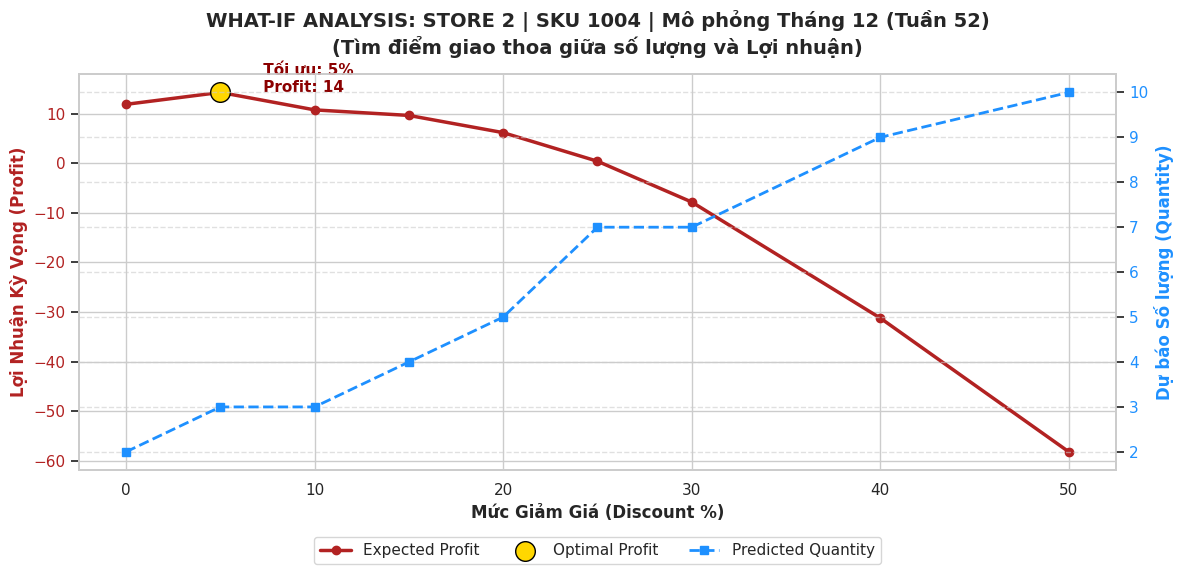


--------------------------------------------------
BẢNG KỊCH BẢN TÀI CHÍNH (STORE 2 - SKU 1004)
--------------------------------------------------


,discount_pct,sim_net_price,pred_qty,expected_revenue,expected_profit
0,0%,23.52,2,47.03,11.87
1,5%,22.34,3,67.02,14.28
2,10%,21.16,3,63.49,10.75
3,15%,19.99,4,79.95,9.63
4,20%,18.81,5,94.06,6.16
5,25%,17.64,7,123.46,0.40
6,30%,16.46,7,115.22,-7.84
7,40%,14.11,9,126.98,-31.24
8,50%,11.76,10,117.58,-58.22


In [21]:
# -- What-if
def simulate_what_if_discount(store_id, sku_id, df_weekly, model, features, target_month=None, target_weekofyear=None):
    """
    Hàm mô phỏng các kịch bản giảm giá cho 1 Store-SKU cụ thể ở tuần gần nhất
    - Có thể truyền thêm target_month và target_weekofyear để giả lập mùa vụ.
    """
    # Lấy dữ liệu của tuần gần nhất làm điểm xuất phát
    latest_data = df_weekly[(df_weekly['store_id'] == store_id) &
                            (df_weekly['sku_id'] == sku_id)].sort_values('week').tail(1).copy()

    if latest_data.empty:
        print(f"⚠️ Không tìm thấy lịch sử bán hàng cho Store {store_id} - SKU {sku_id}")
        return None

    # Phục hồi giá gốc trước khi có khuyến mãi cũ
    old_net_price = latest_data['net_price'].values[0]
    old_discount = latest_data['discount_pct'].values[0]
    cost_price = latest_data['cost_price'].values[0]

    # Tránh lỗi chia cho 0 nếu old_discount = 100%
    base_price = old_net_price / (1 - old_discount/100) if old_discount != 100 else old_net_price

    # Tạo các kịch bản giảm giá
    test_discounts = [0, 5, 10, 15, 20, 25, 30, 40, 50]
    results = []

    # Chuẩn bị 1 bảng copy của dòng dữ liệu hiện tại để chạy vòng lặp
    sim_df = pd.concat([latest_data]*len(test_discounts), ignore_index=True)
    sim_df['discount_pct'] = test_discounts

    # --- ĐOẠN BƠM CHIỀU THỜI GIAN (TUỲ CHỌN) ---
    if target_month is not None:
        sim_df['month'] = target_month
    if target_weekofyear is not None:
        sim_df['weekofyear'] = target_weekofyear
    # -------------------------------------------

    # Dự báo toàn bộ kịch bản
    pred_log = model.predict(sim_df[features])
    sim_df['pred_qty'] = np.expm1(pred_log)
    sim_df['pred_qty'] = np.clip(np.round(sim_df['pred_qty']), 0, None) # Làm tròn số lượng

    # Tính doanh thu và lợi nhuận
    sim_df['sim_net_price'] = base_price * (1 - sim_df['discount_pct'] / 100.0)
    sim_df['expected_revenue'] = sim_df['pred_qty'] * sim_df['sim_net_price']
    sim_df['expected_profit'] = sim_df['pred_qty'] * (sim_df['sim_net_price'] - cost_price)

    final_results = sim_df[['discount_pct', 'sim_net_price', 'pred_qty', 'expected_revenue', 'expected_profit']]

    # Tìm điểm tối ưu Lợi Nhuận
    best_idx = final_results['expected_profit'].idxmax()
    best_discount = final_results.loc[best_idx, 'discount_pct']
    best_profit = final_results.loc[best_idx, 'expected_profit']
    best_qty = final_results.loc[best_idx, 'pred_qty']

    # -- Trực quan hóa kết quả
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Đường lợi nhuận (Màu đỏ)
    ax1.plot(final_results['discount_pct'], final_results['expected_profit'],
             marker='o', color='firebrick', linewidth=2.5, label='Expected Profit')
    ax1.set_xlabel('Mức Giảm Giá (Discount %)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Lợi Nhuận Kỳ Vọng (Profit)', color='firebrick', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='firebrick')

    # Đánh dấu điểm Optimal
    ax1.scatter(best_discount, best_profit, color='gold', s=200, edgecolor='black', zorder=5, label='Optimal Profit')
    ax1.annotate(f' Tối ưu: {best_discount}%\n Profit: {best_profit:,.0f}',
                 xy=(best_discount, best_profit), xytext=(best_discount+2, best_profit),
                 fontsize=11, fontweight='bold', color='darkred')

    # Trục Y phụ - đường số lượng bán (Màu xanh)
    ax2 = ax1.twinx()
    ax2.plot(final_results['discount_pct'], final_results['pred_qty'],
             marker='s', linestyle='--', color='dodgerblue', linewidth=2, label='Predicted Quantity')
    ax2.set_ylabel('Dự báo Số lượng (Quantity)', color='dodgerblue', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='dodgerblue')

    # Xử lý title hiển thị thời gian nếu có truyền vào
    time_str = f"| Mô phỏng Tháng {target_month} (Tuần {target_weekofyear})" if target_month and target_weekofyear else ""
    plt.title(f'WHAT-IF ANALYSIS: STORE {store_id} | SKU {sku_id} {time_str}\n(Tìm điểm giao thoa giữa số lượng và Lợi nhuận)',
              fontsize=14, fontweight='bold', pad=15)

    # Gộp Legend
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    print("\n" + "-"*50)
    print(f"BẢNG KỊCH BẢN TÀI CHÍNH (STORE {store_id} - SKU {sku_id})")
    print("-"*50)
    display(final_results.style.format({
        "discount_pct": "{:.0f}%",
        "sim_net_price": "{:,.2f}",
        "pred_qty": "{:,.0f}",
        "expected_revenue": "{:,.2f}",
        "expected_profit": "{:,.2f}"
    }).background_gradient(subset=['expected_profit'], cmap='RdYlGn'))

    return final_results


# -- Chạy thử kịch bản (Giả lập Noel)
df_whatif_noel = simulate_what_if_discount(
    store_id= 2,
    sku_id= 1004,
    df_weekly=weekly,
    model=final_model,
    features=features,
    target_month=12,
    target_weekofyear=52
)

## ***5.2. Optimization toàn bộ***

[*] Chế độ đang chạy: PROFIT MAXIMIZATION
[*] Đang phân loại và tìm điểm vàng (Golden Point)...


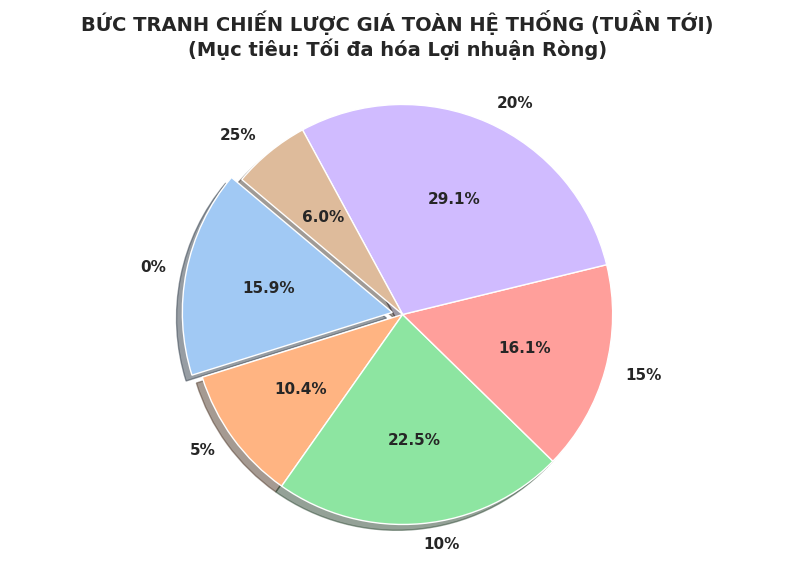


=> Top 5 Gợi ý hành động từ AI:


,store_id,sku_id,base_price,cost_price,Optimal_Discount_%,sim_net_price,pred_qty,expected_revenue,expected_profit
40000,1,1001,164.56,103.44,20,131.65,7,921.54,197.46
40001,1,1002,13.73,8.96,20,10.98,8,87.87,16.19
40002,1,1003,12.00,7.47,20,9.60,4,38.40,8.52
40003,1,1004,25.30,17.58,20,20.24,6,121.44,15.96
4,1,1005,15.93,13.68,0,15.93,3,47.79,6.75


In [22]:
# -- Hàm Global optimization
def run_global_optimization(df_weekly, model, features, objective="profit"):
    """
    Quét toàn bộ Store-SKU, giả lập kịch bản và tìm ra mức giá tối ưu nhất.
    - objective="profit": Tìm mức giảm giá để LỢI NHUẬN cao nhất.
    - objective="clearance": Xả kho (Đẩy Volume lên cao nhất, nhưng giữ mức lỗ thấp nhất có thể).
    """
    print(f"[*] Chế độ đang chạy: {objective.upper()} MAXIMIZATION")

    # Lọc lấy tuần gần nhất của các cặp Store-SKU
    latest_idx = df_weekly.groupby(['store_id', 'sku_id'])['week'].idxmax()
    latest_data = df_weekly.loc[latest_idx].copy()

    # Phục hồi giá gốc
    latest_data['base_price'] = np.where(
        latest_data['discount_pct'] != 100,
        latest_data['net_price'] / (1 - latest_data['discount_pct'] / 100.0),
        latest_data['net_price']
    )

    # Tạo kịch bản song song (0% -> 50%)
    test_discounts = [0, 5, 10, 15, 20, 25, 30, 40, 50]
    scenarios = []

    for d in test_discounts:
        temp = latest_data.copy()
        temp['sim_discount_pct'] = d
        # Cập nhật biến discount_pct để đưa vào model dự báo
        temp['discount_pct'] = d
        temp['sim_net_price'] = temp['base_price'] * (1 - d / 100.0)
        scenarios.append(temp)

    df_sim = pd.concat(scenarios, ignore_index=True)

    # Batch Prediction
    df_sim['pred_log'] = model.predict(df_sim[features])
    df_sim['pred_qty'] = np.clip(np.round(np.expm1(df_sim['pred_log'])), 0, None)

    # Tính toán tài chính
    df_sim['expected_revenue'] = df_sim['pred_qty'] * df_sim['sim_net_price']
    df_sim['expected_profit'] = df_sim['pred_qty'] * (df_sim['sim_net_price'] - df_sim['cost_price'])

    print("[*] Đang phân loại và tìm điểm vàng (Golden Point)...")

    # Rẽ nhánh chiến lược
    if objective == "profit":
        # Chọn dòng có Profit cao nhất cho mỗi cặp Store-SKU
        best_idx = df_sim.groupby(['store_id', 'sku_id'])['expected_profit'].idxmax()
        df_optimal = df_sim.loc[best_idx].copy()

    elif objective == "clearance":
        # Thuật toán Xả kho thông minh:
        # Bước 1: Tìm Volume bán ra cao nhất có thể đạt được.
        # Bước 2: Trong các mức discount đạt được Max Volume đó, chọn mức giảm THẤP NHẤT để đỡ mất tiền.
        def get_smart_clearance(group):
            max_qty = group['pred_qty'].max()
            best_scenarios = group[group['pred_qty'] == max_qty]
            # Lấy kịch bản có Profit cao nhất trong đám bán được nhiều hàng nhất
            best_profit_idx = best_scenarios['expected_profit'].idxmax()
            return group.loc[best_profit_idx]

        df_optimal = df_sim.groupby(['store_id', 'sku_id']).apply(get_smart_clearance).reset_index(drop=True)

    # Sắp xếp lại cột cho đẹp
    cols = ['store_id', 'sku_id', 'base_price', 'cost_price', 'sim_discount_pct',
            'sim_net_price', 'pred_qty', 'expected_revenue', 'expected_profit']
    df_optimal = df_optimal[cols].rename(columns={'sim_discount_pct': 'Optimal_Discount_%'})

    return df_optimal

# -- Chạy thực tế
# Tối ưu lợi nhuận
global_profit_df = run_global_optimization(weekly, final_model, features, objective="profit")

# Thống kê tỷ lệ phân bổ
distribution = global_profit_df['Optimal_Discount_%'].value_counts(normalize=True).reset_index()
distribution.columns = ['Mức Khuyến Mãi (%)', 'Tỷ trọng Store-SKU']
distribution['Tỷ trọng Store-SKU'] = distribution['Tỷ trọng Store-SKU'] * 100
distribution = distribution.sort_values('Mức Khuyến Mãi (%)')

# Trực quan hóa
plt.figure(figsize=(10, 6))
colors = sns.color_palette("pastel")[0:len(distribution)]
explode = [0.05 if x == 0 else 0 for x in distribution['Mức Khuyến Mãi (%)']] # Nhấn mạnh nhóm Không giảm giá

plt.pie(distribution['Tỷ trọng Store-SKU'], labels=distribution['Mức Khuyến Mãi (%)'].astype(str) + "%",
        autopct='%1.1f%%', startangle=140, colors=colors, explode=explode, shadow=True,
        textprops={'fontsize': 11, 'fontweight': 'bold'})

plt.title("BỨC TRANH CHIẾN LƯỢC GIÁ TOÀN HỆ THỐNG (TUẦN TỚI)\n(Mục tiêu: Tối đa hóa Lợi nhuận Ròng)",
          fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')
plt.show()

# Hiển thị 5 SKU gợi ý đầu tiên
print("\n=> Top 5 Gợi ý hành động từ AI:")
display(global_profit_df.head().style.format({
    "base_price": "{:,.2f}", "cost_price": "{:,.2f}", "sim_net_price": "{:,.2f}",
    "pred_qty": "{:,.0f}", "expected_revenue": "{:,.2f}", "expected_profit": "{:,.2f}"
}).background_gradient(subset=['expected_profit'], cmap='Greens'))